In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

Cleaned version of titanic datasets

In [5]:
titan_df = pd.read_csv("../data/titanic_clean.csv")

print(titan_df.shape)
print(titan_df.dtypes)
print(f"\n{titan_df.head()}")


(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
FamilySize       int64
dtype: object

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch           

In [6]:
titan_df.info()
titan_df.columns

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize'],
      dtype='str')

In [7]:
print(titan_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64


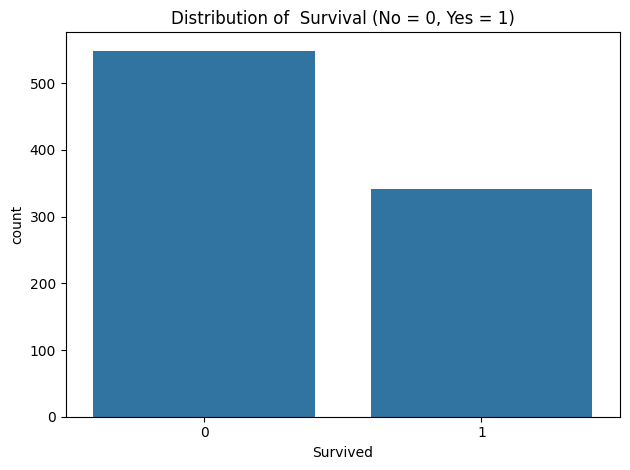

In [8]:
sns.countplot(data=titan_df, x="Survived")
plt.title("Distribution of  Survival (No = 0, Yes = 1)")
plt.tight_layout()
plt.show()

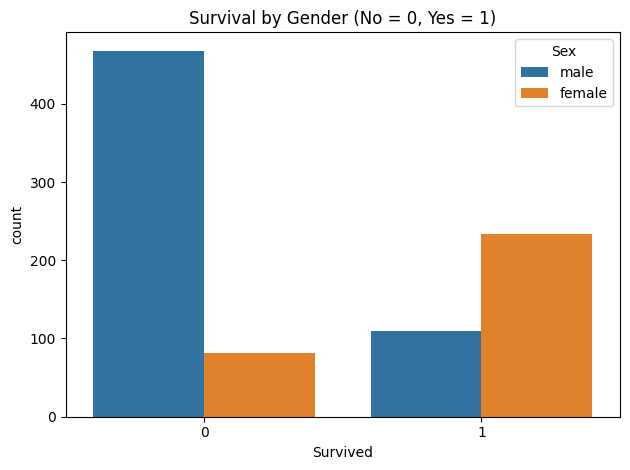

In [9]:
sns.countplot(data=titan_df, x="Survived", hue="Sex")
plt.title("Survival by Gender (No = 0, Yes = 1)")
plt.tight_layout()
plt.show()

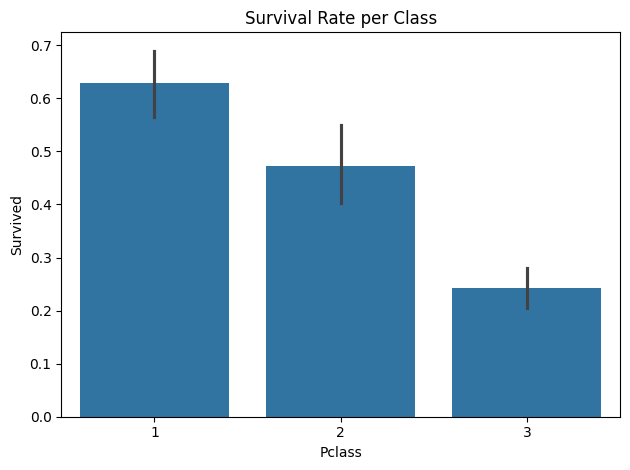

In [10]:
sns.barplot(data=titan_df, x='Pclass', y='Survived')
plt.title('Survival Rate per Class')
plt.tight_layout()
plt.show()

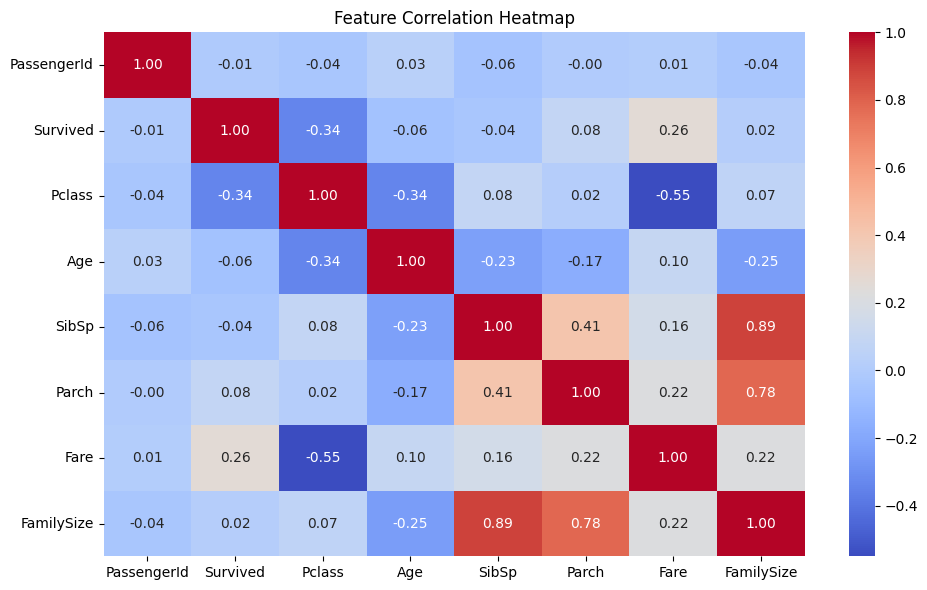

In [11]:
# Select only numeric columns for correlation
numeric_df = titan_df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [12]:
X = titan_df.drop(['Survived', 'Name', 'Ticket', 'PassengerId'], axis=1)
#Drop the target and columns that are text-heavy/unique IDs

y = titan_df['Survived']

X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)
#Convert categorical text into numbers (One-Hot Encoding)
# This turns 'Sex' into 'Sex_male' (0 or 1) and creates columns for Embarked ports



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size", {X_train.shape})
print("Testing set size", {X_test.shape})


Training set size {(712, 9)}
Testing set size {(179, 9)}


In [13]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model_lgr = LogisticRegression()
model_lgr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred_lgr = model_lgr.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_lgr)
print(f"Accuracy:{accuracy:.4f} \n")

cm = confusion_matrix(y_test, y_pred_lgr)
print(f"\n Confusion:{cm} \n ")

cr = classification_report(y_test, y_pred_lgr)
print(f" \n Classificatioin Report:{ cr} \n")

roc = roc_auc_score(y_test, model_lgr.predict_proba(X_test_scaled)[:, 1])
print(f" \n Roc:{roc: .4f} ")

Accuracy:0.8101 


 Confusion:[[90 15]
 [19 55]] 
 
 
 Classificatioin Report:              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179
 

 
 Roc: 0.8817 
 


In [ ]:
model_rfc = RandomForestClassifier(n_estimators=100, random_state=42)
model_rfc.fit(X_train_scaled, y_train)

y_pred_rfc = model_rfc.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_rfc)
print(f"\n Accuracy:{accuracy:.4f} \n")

cm = confusion_matrix(y_test, y_pred_rfc)
print(f"\n Confusion:{cm} \n ")

cr = classification_report(y_test, y_pred_rfc)
print(f" \n Classificatioin Report:{ cr} \n")

roc = roc_auc_score(y_test, model_rfc.predict_proba(X_test_scaled)[:, 1])
print(f" \n Roc:{roc: .4f} ")


 Accuracy:0.8268 


 Confusion:[[91 14]
 [17 57]] 
 
 
 Classificatioin Report:              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179
 

 
 Roc: 0.8958 
 


In [19]:
model_xgb = XGBClassifier(n_estimators = 100, random_state = 42, eval_metric = 'logloss')
model_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = model_xgb.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred_xgb)
print(f"\nConfusion Matrix:\n{cm}")

cr = classification_report(y_test, y_pred_xgb)
print(f"\nClassification Report:\n{cr}")

roc = roc_auc_score(y_test, model_xgb.predict_proba(X_test_scaled)[:, 1])
print(f"\nROC AUC: {roc:.4f}")


XGBoost Accuracy: 0.7989

Confusion Matrix:
[[88 17]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


ROC AUC: 0.8754


In [ ]:
results = { 
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.8101, 0.8268, 0.7989],
    "ROC AUC": [0.8817, 0.8958, 0.8754],
    "F1 Survived": [0.76, 0.79, 0.75]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))